STEP 1: Load & Understand the Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("DSL-StrongPasswordData.csv")  # replace with your file path

print(df.shape)
print(df.head())
print(df.info())

(20400, 34)
  subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0    s002             1    1    0.1491       0.3979       0.2488  0.1069   
1    s002             1    2    0.1111       0.3451       0.2340  0.0694   
2    s002             1    3    0.1328       0.2072       0.0744  0.0731   
3    s002             1    4    0.1291       0.2515       0.1224  0.1059   
4    s002             1    5    0.1249       0.2317       0.1068  0.0895   

   DD.t.i  UD.t.i     H.i  ...     H.a  DD.a.n  UD.a.n     H.n  DD.n.l  \
0  0.1674  0.0605  0.1169  ...  0.1349  0.1484  0.0135  0.0932  0.3515   
1  0.1283  0.0589  0.0908  ...  0.1412  0.2558  0.1146  0.1146  0.2642   
2  0.1291  0.0560  0.0821  ...  0.1621  0.2332  0.0711  0.1172  0.2705   
3  0.2495  0.1436  0.1040  ...  0.1457  0.1629  0.0172  0.0866  0.2341   
4  0.1676  0.0781  0.0903  ...  0.1312  0.1582  0.0270  0.0884  0.2517   

   UD.n.l     H.l  DD.l.Return  UD.l.Return  H.Return  
0  0.2583  0.1338       0.3509

In [ ]:
#STEP 2: Basic Data Analysis
print(df.describe())
print(df['subject'].value_counts())
#STEP 3: Check Missing Values
print("Check Missing Values")
print(df.isnull().sum())

       sessionIndex           rep      H.period   DD.period.t   UD.period.t  \
count  20400.000000  20400.000000  20400.000000  20400.000000  20400.000000   
mean       4.500000     25.500000      0.093379      0.264148      0.170769   
std        2.291344     14.431223      0.029626      0.220534      0.226836   
min        1.000000      1.000000      0.001400      0.018700     -0.235800   
25%        2.750000     13.000000      0.074400      0.146900      0.049800   
50%        4.500000     25.500000      0.089500      0.205950      0.108700   
75%        6.250000     38.000000      0.107900      0.306450      0.212400   
max        8.000000     50.000000      0.376100     12.506100     12.451700   

                H.t        DD.t.i        UD.t.i           H.i        DD.i.e  \
count  20400.000000  20400.000000  20400.000000  20400.000000  20400.000000   
mean       0.085727      0.169085      0.083358      0.081565      0.159372   
std        0.027424      0.123546      0.125755    

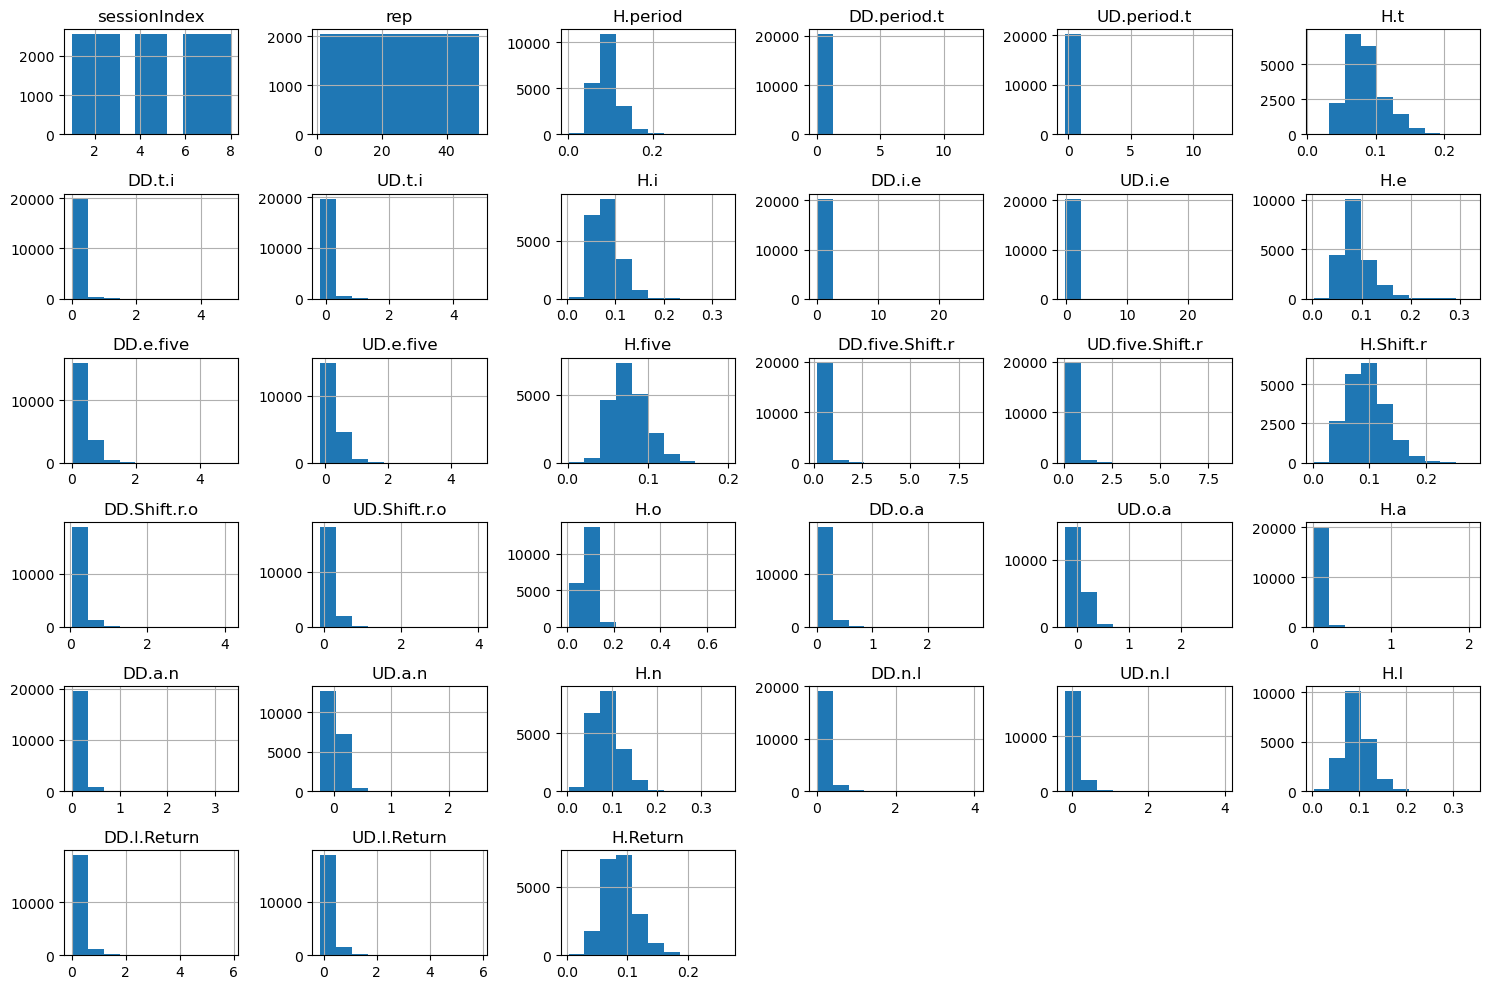

In [ ]:
#STEP 4: Distribution of Features
import matplotlib.pyplot as plt

df.drop(columns=['subject']).hist(figsize=(15,10))
plt.tight_layout()
plt.show()

C:\Users\gf63\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


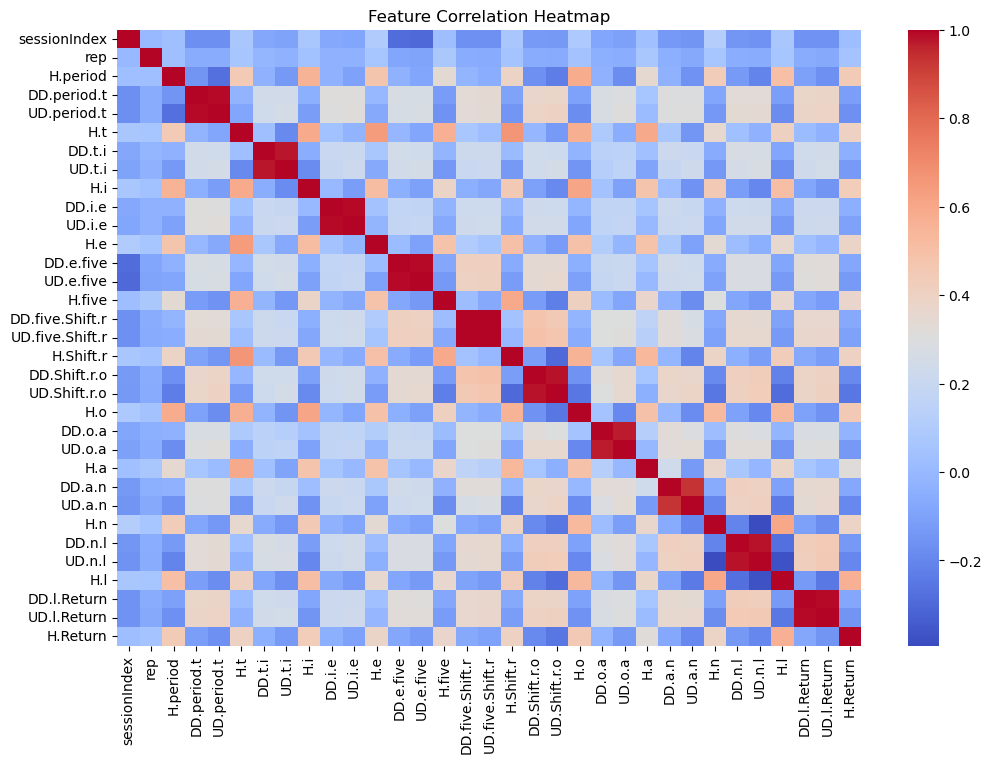

In [ ]:
#STEP 5: Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['subject']).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
print(df['subject'].unique())

['s002' 's003' 's004' 's005' 's007' 's008' 's010' 's011' 's012' 's013'
 's015' 's016' 's017' 's018' 's019' 's020' 's021' 's022' 's024' 's025'
 's026' 's027' 's028' 's029' 's030' 's031' 's032' 's033' 's034' 's035'
 's036' 's037' 's038' 's039' 's040' 's041' 's042' 's043' 's044' 's046'
 's047' 's048' 's049' 's050' 's051' 's052' 's053' 's054' 's055' 's056'
 's057']


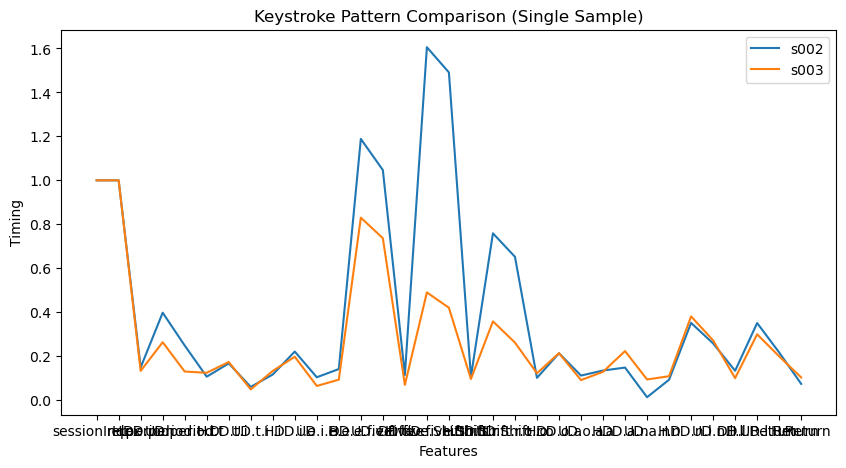

In [ ]:
import matplotlib.pyplot as plt

# Select two users
users = df['subject'].unique()
user1 = df[df['subject'] == users[0]]
user2 = df[df['subject'] == users[1]]

# Plot one sample
plt.figure(figsize=(10,5))

plt.plot(user1.iloc[0].drop('subject'), label=users[0])
plt.plot(user2.iloc[0].drop('subject'), label=users[1])

plt.legend()
plt.title("Keystroke Pattern Comparison (Single Sample)")
plt.xlabel("Features")
plt.ylabel("Timing")
plt.show()

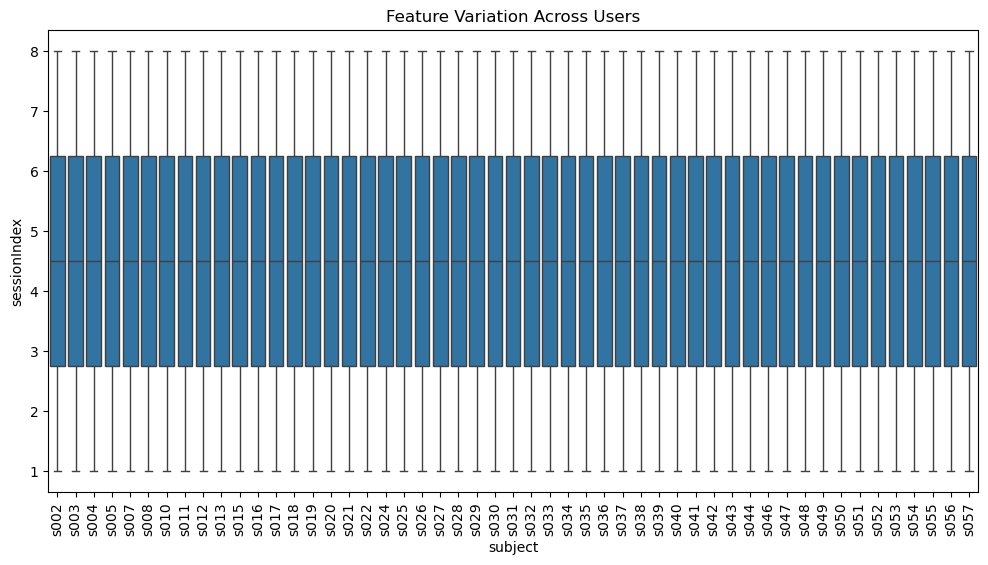

In [ ]:
#STEP 7: Boxplot (Variation Across Users)
plt.figure(figsize=(12,6))
sns.boxplot(x='subject', y=df.columns[1], data=df)
plt.xticks(rotation=90)
plt.title("Feature Variation Across Users")
plt.show()

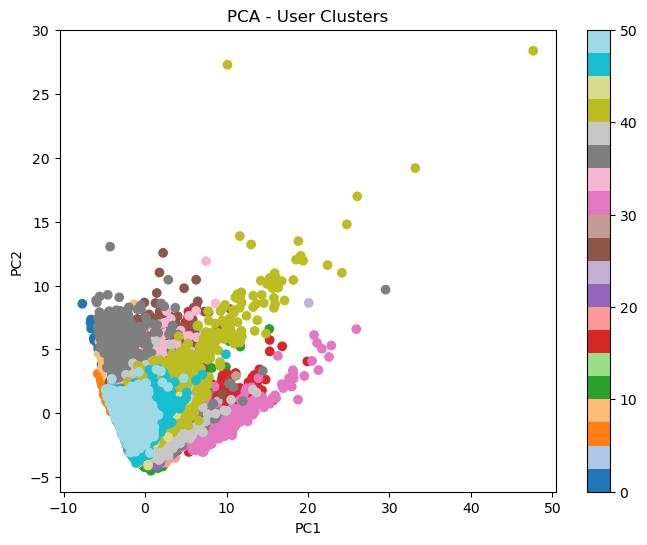

In [ ]:
#STEP 8: PCA Visualization
#Reduce 34 features → 2D visualization


#Step 1: Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
#Step 2: Use encoded labels in PCA plot
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Features and labels
X = df.drop(columns=['subject'])
y = df['subject']

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded, cmap='tab20')

plt.title("PCA - User Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter)
plt.show()

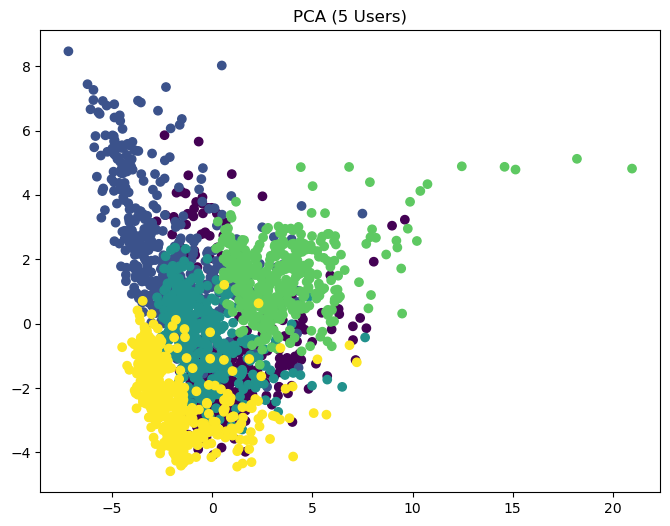

In [ ]:
#Cleaner Visualization)
#Since you have 51 users, colorbar becomes messy.
#Use only a few users:
# Select first 5 users
selected_users = df['subject'].unique()[:5]
df_small = df[df['subject'].isin(selected_users)]

X = df_small.drop(columns=['subject'])
y = df_small['subject']

# Encode
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale + PCA
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded)

plt.title("PCA (5 Users)")
plt.show()

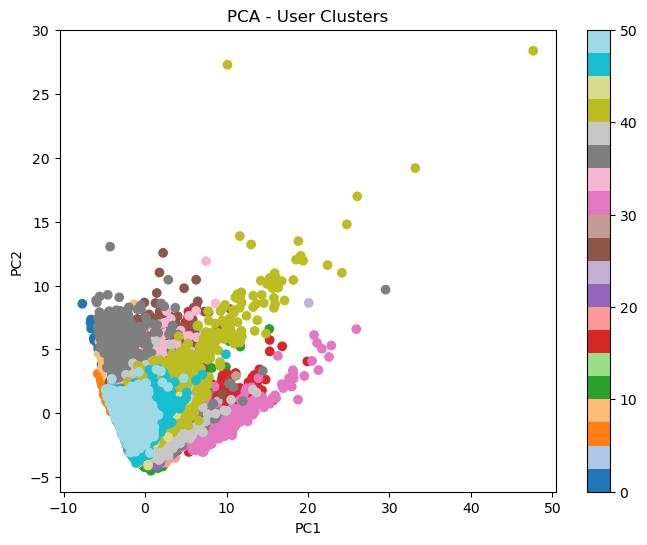

In [ ]:
#Final PCA Code (Use This)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# Features & labels
X = df.drop(columns=['subject'])
y = df['subject']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded, cmap='tab20')

plt.title("PCA - User Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)
plt.show()

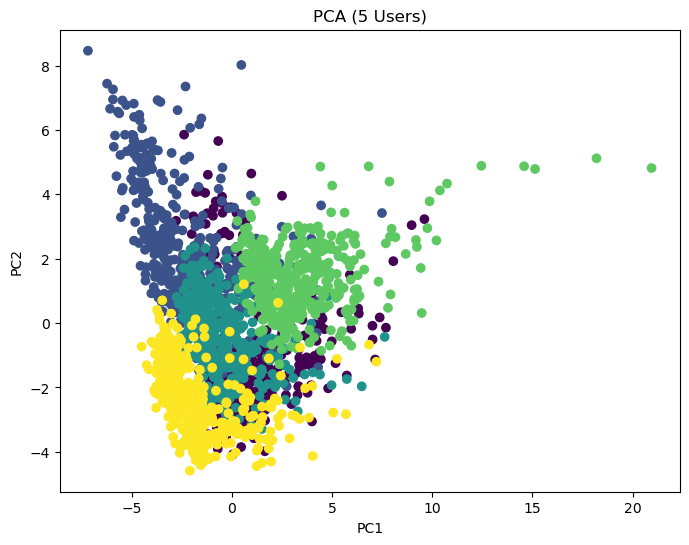

In [ ]:
selected_users = df['subject'].unique()[:5]
df_small = df[df['subject'].isin(selected_users)]

X = df_small.drop(columns=['subject'])
y = df_small['subject']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded)

plt.title("PCA (5 Users)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()